In [16]:
import os
import sys
from enum import unique
from platform import system

import cv2
import numpy as np
from numpy.ma.core import indices
from tqdm import tqdm
from ultralytics import YOLO
import time
import torch
import torchvision.transforms as transforms

from mmpose.apis import init_model
from models.vitpose.models.backbone.vit import ViT
from models.vitpose.models.detectors.top_down import TopDown
from models.vitpose.models.head.topdown_heatmap_simple_head import TopdownHeatmapSimpleHead
from models.vitpose.models.head import topdown_heatmap_simple_head
from mmpose.registry import MODELS

from vit_pose import direct_inference

#import src
sys.path.insert(0, os.path.join(os.getcwd(), 'models', 'rtdetr'))
from src.core import YAMLConfig

# Configuration

In [17]:
FRAMES_DIR = 'frames_0.5'
FRAMES_UPSCALED_DIR = 'frames_0.5_upscaled'
SKELETON_DIR = 'skeletons_yolo_11_new'
SKELETON_UPSCALED_DIR = 'skeletons_yolo_11_upscaled_2'

YOLO_MODEL_DETECTION = 'models/yolo/yolo11x.pt'
SUPER_RESOLUTION_MODEL_PATH = 'models/super_resolution'
VITPOSE_MODEL_PATH = 'models/vitpose'

# Models
_DETECTION_MODEL = None
_VITPOSE_MODEL = None
_DATASET_INFO = None

# --- Super-resolution setup ---
_SR_NET = None
_SR_SCALE = 4
_SR_PB = os.path.join(SUPER_RESOLUTION_MODEL_PATH, "ESPCN_x4.pb")

# System
_SYSTEM = sys.platform
_DEVICE = "mps" if _SYSTEM == "darwin" else "cuda"

# Register components

In [18]:
MODELS.register_module(module=ViT, force=True)
MODELS.register_module(module=TopDown, force=True)
MODELS.register_module(module=TopdownHeatmapSimpleHead, force=True)

models.vitpose.models.head.topdown_heatmap_simple_head.TopdownHeatmapSimpleHead

In [32]:
COCO_CLASSES = {0: u'__background__',
 1: u'person',
 2: u'bicycle',
 3: u'car',
 4: u'motorcycle',
 5: u'airplane',
 6: u'bus',
 7: u'train',
 8: u'truck',
 9: u'boat',
 10: u'traffic light',
 11: u'fire hydrant',
 12: u'stop sign',
 13: u'parking meter',
 14: u'bench',
 15: u'bird',
 16: u'cat',
 17: u'dog',
 18: u'horse',
 19: u'sheep',
 20: u'cow',
 21: u'elephant',
 22: u'bear',
 23: u'zebra',
 24: u'giraffe',
 25: u'backpack',
 26: u'umbrella',
 27: u'handbag',
 28: u'tie',
 29: u'suitcase',
 30: u'frisbee',
 31: u'skis',
 32: u'snowboard',
 33: u'sports ball',
 34: u'kite',
 35: u'baseball bat',
 36: u'baseball glove',
 37: u'skateboard',
 38: u'surfboard',
 39: u'tennis racket',
 40: u'bottle',
 41: u'wine glass',
 42: u'cup',
 43: u'fork',
 44: u'knife',
 45: u'spoon',
 46: u'bowl',
 47: u'banana',
 48: u'apple',
 49: u'sandwich',
 50: u'orange',
 51: u'broccoli',
 52: u'carrot',
 53: u'hot dog',
 54: u'pizza',
 55: u'donut',
 56: u'cake',
 57: u'chair',
 58: u'couch',
 59: u'potted plant',
 60: u'bed',
 61: u'dining table',
 62: u'toilet',
 63: u'tv',
 64: u'laptop',
 65: u'mouse',
 66: u'remote',
 67: u'keyboard',
 68: u'cell phone',
 69: u'microwave',
 70: u'oven',
 71: u'toaster',
 72: u'sink',
 73: u'refrigerator',
 74: u'book',
 75: u'clock',
 76: u'vase',
 77: u'scissors',
 78: u'teddy bear',
 79: u'hair drier',
 80: u'toothbrush'}

# Upscaling images

# Extract frames from videos

In [19]:
def extract_frames_from_videos(input_dir='data/Motion_Emotion', output_dir='frames_0.5', 
                               fps=2, max_frames=None, video_names=None):
    """
    Extrakce snímků z videí na zadané FPS
    
    Args:
        input_dir: str - složka se vstupními videi (.mp4)
        output_dir: str - výstupní složka pro snímky
        fps: int - počet snímků za sekundu k extrakci (default: 2)
        max_frames: int - maximální počet snímků na video (None = všechny)
        video_names: list - seznam názvů videí k zpracování (None = všechna)
    
    Returns:
        None (ukládá .jpg soubory do output_dir)
    """
    if not os.path.exists(input_dir):
        print(f"Vstupní složka neexistuje: {input_dir}")
        return
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Získá seznam MP4 souborů
    all_videos = [f for f in os.listdir(input_dir) if f.endswith('.mp4')]
    
    # Filtruje podle video_names pokud je zadáno
    if video_names is not None:
        videos_to_process = []
        for name in video_names:
            # Pokud název neobsahuje .mp4, přidlý ho
            if not name.endswith('.mp4'):
                name = name + '.mp4'
            if name in all_videos:
                videos_to_process.append(name)
            else:
                print(f"Video {name} nenalezeno v {input_dir}")
    else:
        videos_to_process = all_videos
    
    if not videos_to_process:
        print("Žádná videa ke zpracování")
        return
    
    print(f"Zpracování {len(videos_to_process)} videí z {input_dir}")
    print(f"FPS: {fps}, Max snímků: {max_frames if max_frames else 'všechny'}")
    print("="*70)
    
    total_saved = 0
    
    for fname in tqdm(videos_to_process, desc="Extrakce snímků"):
        video_path = os.path.join(input_dir, fname)
        base = os.path.splitext(fname)[0]
        out_dir = os.path.join(output_dir, base)
        os.makedirs(out_dir, exist_ok=True)
        
        cap = cv2.VideoCapture(video_path)
        
        # Zjisti FPS videa
        total_fps = cap.get(cv2.CAP_PROP_FPS) or 25
        frame_interval = int(total_fps / fps) if total_fps >= fps else 1
        
        count = 0
        saved = 0
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            # Uloží jen každý n-tý frame podle FPS
            if count % frame_interval == 0:
                out_path = os.path.join(out_dir, f"{base}_{saved:04d}.jpg")
                cv2.imwrite(out_path, frame)
                saved += 1
                if max_frames and saved >= max_frames:
                    break
            count += 1
        
        cap.release()
        total_saved += saved
        print(f"✓ {fname}: {saved} snímků")
    
    print("="*70)
    print(f"Celkem extrahováno: {total_saved} snímků")
    print(f"Uloženo do: {output_dir}")


# extract_frames_from_videos(
#     input_dir='data/Motion_Emotion',
#     output_dir='frames_0.5',
#     fps=2,
#     max_frames=None,  # None = všechny snímky
#     video_names=None  # None = všechna videa, nebo ['001', '002', '003']
# )

In [20]:
def upscale_img_folder(folder_name):
    # Paths
    input_frames = os.path.join(FRAMES_DIR, folder_name)
    output_frames = os.path.join(FRAMES_UPSCALED_DIR, folder_name)

    if not os.path.exists(input_frames):
        print(f"Input folder not found: {input_frames}")
        return

    print("Step 1: Creating upscaled frames...")
    start_time = time.time()

    os.makedirs(output_frames, exist_ok=True)
    files = sorted([f for f in os.listdir(input_frames) if f.endswith('.jpg')])

    init_super_resolution_model()

    for fname in tqdm(files, desc=f"Upscaling {os.path.basename(input_frames)}"):
        input_path = os.path.join(input_frames, fname)
        output_path = os.path.join(output_frames, fname)

        if os.path.exists(output_path):
            continue

        img = cv2.imread(input_path)
        if img is None:
            continue

        # Apply super-resolution or high-quality upscaling
        upscaled_img = apply_super_resolution(img)

        # Save upscaled image
        cv2.imwrite(output_path, upscaled_img)

    upscale_time = time.time() - start_time
    print(f"Upscaling completed in {upscale_time:.2f} seconds")


def init_super_resolution_model():
    """
    Initialize super-resolution model
    """
    global _SR_NET

    if _SR_NET is not None:
        return _SR_NET

    try:
        # Check if dnn_superres is available
        if hasattr(cv2, 'dnn_superres'):
            sr = cv2.dnn_superres.DnnSuperResImpl_create()
        else:
            print("dnn_superres not available in your OpenCV build")
            return None

        # Load model
        sr.readModel(_SR_PB)
        sr.setModel('espcn', _SR_SCALE)

        # Set backend (CPU for compatibility)
        sr.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
        sr.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)

        print("Super-resolution model initialized successfully")
        _SR_NET = sr
        return sr

    except Exception as e:
        print(f"Failed to initialize super-resolution: {e}")
        return None


def apply_super_resolution(img, target_scale=4):
    """
    Apply super-resolution with guaranteed scale factor
    """
    sr = init_super_resolution_model()
    if sr is None:
        height, width = img.shape[:2]
        return cv2.resize(img, (width * target_scale, height * target_scale), interpolation=cv2.INTER_CUBIC)

    try:
        height, width = img.shape[:2]
        target_height, target_width = height * target_scale, width * target_scale

        # Apply super-resolution
        sr_result = sr.upsample(img)

        # If the SR result isn't exactly the target size, resize to match
        sr_height, sr_width = sr_result.shape[:2]
        if sr_height != target_height or sr_width != target_width:
            sr_result = cv2.resize(sr_result, (target_width, target_height), interpolation=cv2.INTER_LANCZOS4)

        return sr_result

    except Exception as e:
        print(f"Super-resolution failed: {e}")
        height, width = img.shape[:2]
        return cv2.resize(img, (width * target_scale, height * target_scale), interpolation=cv2.INTER_CUBIC)

In [21]:
#upscale_img_folder('004')

Step 1: Creating upscaled frames...
dnn_superres not available in your OpenCV build


Upscaling 004: 100%|██████████| 82/82 [00:00<00:00, 54985.28it/s]

Upscaling completed in 0.01 seconds


In [39]:
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image

class RTDETRDetector:
    """RT-DETR detektor osob wrapper"""

    def __init__(self, config_path, checkpoint_path, device='cuda'):
        """
        Inicializace RT-DETR modelu

        Args:
            config_path: Cesta ke konfiguracnimu souboru (.yml)
            checkpoint_path: Cesta k modelu (checkpoint .pth soubor)
            device: 'cuda' nebo 'cpu'

        Returns:
            None
        """
        self.device = device

        cfg = YAMLConfig(config_path, resume=checkpoint_path, PResNet={'pretrained': False})
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        if 'ema' in checkpoint:
            state = checkpoint['ema']['module']
        else:
            state = checkpoint['model']


        # Nacteni vah modelu
        cfg.model.load_state_dict(state, strict=False)

        # Vytvoreni modelu pro inferenci
        class Model(nn.Module):
            def __init__(self, cfg):
                super().__init__()
                self.model = cfg.model.deploy()
                self.postprocessor = cfg.postprocessor.deploy()

            def forward(self, images, orig_target_sizes):
                outputs = self.model(images)
                outputs = self.postprocessor(outputs, orig_target_sizes)
                return outputs

        self.model = Model(cfg).to(device)
        self.model.eval()

        # Transformace obrazku
        self.transforms = T.Compose([
            T.Resize((640, 640)),
            T.ToTensor(),
        ])

        print(f"RT-DETR model nacten uspesne na {device}")

    def detect(self, image_path, conf_threshold=0.6, person_class_id=0):
        """
        Detekce osob na obrazku

        Args:
            image_path: Cesta k obrazku (nebo numpy array/PIL Image)
            conf_threshold: Prah spolehlivosti detekce (0-1)
            person_class_id: COCO ID pro tridu 'osoba' (0)

        Returns:
            boxes: numpy array tvaru (N, 5) s [x1, y1, x2, y2, conf]
        """

         # Nacteni obrazku
        if isinstance(image_path, str):
            im_pil = Image.open(image_path).convert('RGB')
        else:
            if isinstance(image_path, np.ndarray):
                im_pil = Image.fromarray(cv2.cvtColor(image_path, cv2.COLOR_BGR2RGB))
            else:
                im_pil = image_path

        w, h = im_pil.size
        orig_size = torch.tensor([w, h])[None].to(self.device)

        # Transformace a inference
        im_data = self.transforms(im_pil)[None].to(self.device)

        with torch.no_grad():
            labels, boxes, scores = self.model(im_data, orig_size)
            
        # Filtrovani pouze trid 'osoba'
        labels = labels[0].cpu().numpy()
        boxes = boxes[0].cpu().numpy()
        scores = scores[0].cpu().numpy()
        
        labels_set = set(labels)
        for label_id in labels_set:
            print(COCO_CLASSES.get(label_id))

        # Filtr podle tridy a spolehlivosti
        
        person_mask = (labels == person_class_id) & (scores > conf_threshold)
        person_boxes = boxes[person_mask]
        person_scores = scores[person_mask]

        # Spojeni boxu a skore
        if len(person_boxes) > 0:
            result = np.column_stack([person_boxes, person_scores])
        else:
            result = np.array([])

        return result

    def better_detection(self, img):
        """
        Vylepsena detekce s vice zpracovanymi obrazky a konfiguracemi
        Pouziva 4 varianty obrazku (original, CLAHE, histogram eq, gamma)
        a ruzne YOLO konfigurace pro maximalni pokryti

        Args:
            img: numpy array - vstupni obrazek (BGR format)

        Returns:
            boxes: numpy array tvaru (N, 5) s [x1, y1, x2, y2, conf] po NMS
        """
        all_boxes = []
        # Shadow suppression
        rgb_planes = cv2.split(img)
        result_planes = []
        result_norm_planes = []

        for plane in rgb_planes:
            dilated_img = cv2.dilate(plane, np.ones((4,4), np.uint8))
            bg_img = cv2.medianBlur(dilated_img, 7)
            diff_img = 255 - cv2.absdiff(plane, bg_img)
            norm_img = cv2.normalize(diff_img,None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8UC1)
            result_planes.append(diff_img)
            result_norm_planes.append(norm_img)

        result_norm = cv2.merge(result_norm_planes)

        enhanced_imgs = [img]


        # CLAHE enhancement on upscaled image
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3, tileGridSize=(8, 8))
        l = clahe.apply(l)
        enhanced_img = cv2.merge((l, a, b))
        enhanced_img = cv2.cvtColor(enhanced_img, cv2.COLOR_LAB2BGR)
        enhanced_imgs.append(enhanced_img)
        #enhanced_imgs = [enhanced_img]

        # Histogram equalization
        yuv = cv2.cvtColor(result_norm, cv2.COLOR_BGR2YUV)
        yuv[:, :, 0] = cv2.equalizeHist(yuv[:, :, 0])
        enhanced2 = cv2.cvtColor(yuv, cv2.COLOR_YUV2BGR)
        enhanced_imgs.append(enhanced2)

        # Gamma correction
        gamma = 0.8
        enhanced3 = np.power(result_norm / 255.0, gamma) * 255.0
        enhanced3 = enhanced3.astype(np.uint8)
        enhanced_imgs.append(enhanced3)

        # Yolo configuration
        configs = [
            {'conf': 0.65, 'imgsz': 1280, 'iou': 0.6},
            {'conf': 0.60, 'imgsz': 1024, 'iou': 0.6},
            {'conf': 0.60, 'imgsz': 1536, 'iou': 0.6},
            {'conf': 0.55, 'imgsz': 1792, 'iou': 0.7},
            {'conf': 0.4, 'imgsz': 2048, 'iou': 0.6},
        ]

        for img_idx, enhanced_img in enumerate(enhanced_imgs):
            if img_idx == 0:
                config_indices = [0, 2]
            elif img_idx == 1:  # CLAHE
                config_indices = [1, 3]
            elif img_idx == 2:  # Histogram equalized
                config_indices = [0, 4]
            else:  # Gamma corrected
                config_indices = [1]

            for config_idx in config_indices:
                try:
                    #res = model(enhanced_img, verbose=True, **configs[config_idx])
                    result = self.detect(enhanced_img, conf_threshold=0.3)
                    if result is not None and len(result) > 0:
                        all_boxes.append(result)
                except Exception as e:
                    print(f"Detection failed: {e}")
                    continue

        if not all_boxes:
            return np.array([])

        combined_boxes = np.vstack(all_boxes)
        #combined_boxes = self.local_redetect(combined_boxes, iou_threshold=0.4, img=enhanced_img)
        combined_boxes = self.nms_boxes(combined_boxes, iou_threshold=0.5)

        return combined_boxes


    def nms_boxes(self, boxes, iou_threshold):
        """
        Non-Maximum Suppression pro odstraneni duplicitnich detekcí

        Args:
            boxes: numpy array tvaru (N, 5) s [x1, y1, x2, y2, conf]
            iou_threshold: prah IoU pro potlaceni (0-1)

        Returns:
            boxes: numpy array po NMS tvaru (M, 5) kde M <= N
        """
        x1, y1, x2, y2, scores = boxes.T
        #boxes = np.array(boxes)

        indices = scores.argsort()[::-1]

        keep =[]
        while len(indices) > 0:
            i = indices[0]
            keep.append(i)

            xx1 = np.maximum(x1[i], x1[indices[1:]])
            yy1 = np.maximum(y1[i], y1[indices[1:]])
            xx2 = np.minimum(x2[i], x2[indices[1:]])
            yy2 = np.minimum(y2[i], y2[indices[1:]])

            w = np.maximum(0, xx2 - xx1)
            h = np.maximum(0, yy2 - yy1)
            inter = w * h
            area_i = (x2[i] - x1[i]) * (y2[i] - y1[i])
            area_rest = (x2[indices[1:]] - x1[indices[1:]]) * (y2[indices[1:]] - y1[indices[1:]])
            iou = inter / (area_i + area_rest - inter + 1e-6)

            indices = indices[1:][iou < iou_threshold]

        return boxes[keep]


    def local_redetect(self, boxes, iou_threshold, img):
        """
        Lokalni re-detekce v oblastech s prekryvajicimi se detekcemi
        Hleda clustery detekcí s vysokym IoU a provadi re-detekci v jejich oblasti

        Args:
            boxes: numpy array tvaru (N, 5) s [x1, y1, x2, y2, conf]
            iou_threshold: prah IoU pro shlukování (0-1)
            img: numpy array - vstupni obrazek pro re-detekci

        Returns:
            boxes: numpy array s re-detekovanymi boxy tvaru (M, 5)
        """
        final_boxes = []
        x1, x2, y1, y2, scores = boxes.T
        indices = scores.argsort()[::-1]

        processed_indices = []
        while len(indices) > 0:
            i = indices[0]

            if i in processed_indices:
                indices = indices[1:]
                continue

            current_box = boxes[i]

            xx1 = np.maximum(x1[i], x1[indices[1:]])
            yy1 = np.maximum(y1[i], y1[indices[1:]])
            xx2 = np.minimum(x2[i], x2[indices[1:]])
            yy2 = np.minimum(y2[i], y2[indices[1:]])

            w = np.maximum(0, xx2 - xx1)
            h = np.maximum(0, yy2 - yy1)
            inter = w * h
            area_i = (x2[i] - x1[i]) * (y2[i] - y1[i])
            area_rest = (x2[indices[1:]] - x1[indices[1:]]) * (y2[indices[1:]] - y1[indices[1:]])
            iou = inter / (area_i + area_rest - inter + 1e-6)

            boxes_to_redetect_indices = indices[1:][iou > iou_threshold]
            cluster_indices = np.concatenate(([i], boxes_to_redetect_indices))
            cluster_boxes = boxes[cluster_indices]

            # 2. Vypočítám minimální x1, y1 a maximální x2, y2 pro celou skupinu
            x_coords = cluster_boxes[:, 0]
            y_coords = cluster_boxes[:, 1]
            x_coords_2 = cluster_boxes[:, 2]
            y_coords_2 = cluster_boxes[:, 3]

            crop_x1 = np.min(x_coords).astype(int)
            crop_y1 = np.min(y_coords).astype(int)
            crop_x2 = np.max(x_coords_2).astype(int)
            crop_y2 = np.max(y_coords_2).astype(int)

            cropped_img = img[crop_y1:crop_y2, crop_x1:crop_x2]
            new_boxes = []
            results = self.detect(cropped_img)

            if len(results) > 0:
                # Detekované boxy mají souřadnice RELATIVNÍ k oříznutému obrázku
                relative_boxes = results[:, :4]
                confs = results[:, 4]

                absolute_boxes = relative_boxes.copy()
                absolute_boxes[:, 0] += crop_x1
                absolute_boxes[:, 1] += crop_y1
                absolute_boxes[:, 2] += crop_x1
                absolute_boxes[:, 3] += crop_y1

                current_new_boxes = np.column_stack([absolute_boxes, confs])
                final_boxes.append(current_new_boxes)

            else:
                final_boxes.append(current_box.reshape(1, -1))

            processed_indices.extend(cluster_indices.tolist())

            indices = indices[1:][iou < iou_threshold]

        if len(final_boxes) > 0:
            return np.vstack(final_boxes)
        else:
            return np.array([])

# 2 stage detection
rtdetr model for detecting and vitpose for extracting skeletons

## Second stage VitPose

In [23]:
from mmpose.apis import inference_topdown
from visualization_helper import visualize_detections


class VitPoseExtractor:
    """Extraktor keypoints pomocí ViTPose modelu"""
    
    def __init__(self, config_file, checkpoint_file, device='cuda'):
        """
        Inicializace ViTPose modelu

        Args:
            config_file: Cesta ke konfiguracnimu souboru (.py)
            checkpoint_file: Cesta k modelu (checkpoint .pth soubor)
            device: 'cuda' nebo 'cpu'

        Returns:
            None
        """
        self.model = init_model(config_file, checkpoint_file, device=device)

    def extract_keypoints(self, img, boxes, visualize=False, save_path=None):
        """
        Extrakce keypoints z obrazku pomoci detekovanych bounding boxu

        Args:
            img: numpy array - vstupni obrazek (BGR format)
            boxes: numpy array tvaru (N, 5) s [x1, y1, x2, y2, conf]
            visualize: bool - zda vizualizovat vysledky
            save_path: str - cesta pro ulozeni vizualizace (None = neulozi)

        Returns:
            skeletons: numpy array tvaru (N, 17, 3) s [x, y, score] pro kazdy keypoint
        """
        if boxes is None or len(boxes) == 0:
            return np.array([])

        skeletons = []
        boxes_without_score = boxes[:, :4].astype(np.float32)

        # Visualize bounding boxes before ViTPose extraction
        if visualize:
            visualize_detections(
                img, boxes, skeletons=None,
                title="YOLO Detections (Stage 1)",
                save_path=save_path.replace('.jpg', '_bboxes.jpg') if save_path else None,
                show=True
            )

        pose_results = inference_topdown(self.model, img, boxes_without_score, "xyxy")

        for result in pose_results:
            if hasattr(result, 'pred_instances'):
                keypoints = result.pred_instances.keypoints[0]
                scores = result.pred_instances.keypoint_scores[0]
                skeleton = np.concatenate([keypoints, scores[:, None]], axis=1)
                skeletons.append(skeleton)

        skeletons_array = np.array(skeletons) if skeletons else np.array([])

        # Visualize with skeletons after ViTPose extraction
        if visualize and len(skeletons_array) > 0:
            visualize_detections(
                img, boxes, skeletons=skeletons_array,
                title="ViTPose Results (Stage 2)",
                save_path=save_path,
                show=True
            )

        return skeletons_array

In [41]:
def two_stage_skeleton_extraction(frames_dir, skeleton_dir, visualize_first_n=3):
    """
    Dvoustupňová extrakce skeletů: RT-DETR detekce + ViTPose keypoints

    Args:
        frames_dir: str - cesta ke složce se snímky
        skeleton_dir: str - výstupní složka pro .npy soubory se skeletony
        visualize_first_n: int - počet prvních snímků k vizualizaci (default: 3)

    Returns:
        None (ukládá .npy soubory do skeleton_dir)
    """
    os.makedirs(skeleton_dir, exist_ok=True)
    vis_dir = os.path.join(skeleton_dir, 'visualizations')
    os.makedirs(vis_dir, exist_ok=True)

    files = sorted(f for f in os.listdir(frames_dir) if f.endswith('.jpg'))

    #yolo_model = YOLO(yolo_model_path)
    device = _DEVICE if (torch.cuda.is_available()) or (torch.backends.mps.is_available()) else 'cpu'
    print(device)

    #RT
    rtdetr_detector = RTDETRDetector(
        'models/rtdetr/configs/rtdetrv2/rtdetrv2_r101vd_6x_coco.yml',
        'models/rtdetr/rtdetrv2_r101vd_6x_coco_from_paddle.pth',
        device=device
    )
    #VitPose
    config_file = 'models/vitpose/configs/ViTPose_huge_crowdpose_256x192_without_training_v3.py'
    checkpoint_file = 'models/vitpose/vitpose-h-multi-crowdpose.pth'
    vitpose_extractor = VitPoseExtractor(config_file, checkpoint_file, device=device)

    total_detections = 0

    for idx, fname in enumerate(tqdm(files, desc=f"Processing {os.path.basename(frames_dir)}")):
        path = os.path.join(frames_dir, fname)
        img = cv2.imread(path)
        if img is None:
            continue

        # Stage 1: YOLO Detection
        #bounding_boxes = yolo_detection(img, yolo_model)
        bounding_boxes = rtdetr_detector.better_detection(img)

        if len(bounding_boxes) == 0:
            skeleton_path = os.path.join(skeleton_dir, fname.replace('.jpg', '.npy'))
            np.save(skeleton_path, np.array([]))
            continue

        # Stage 2: ViTPose - visualize first N frames
        should_visualize = idx < visualize_first_n
        vis_save_path = os.path.join(vis_dir, fname) if should_visualize else None

        skeletons = vitpose_extractor.extract_keypoints(
            img, bounding_boxes,
            visualize=should_visualize,
            save_path=vis_save_path
        )

        skeleton_path = os.path.join(skeleton_dir, fname.replace('.jpg', '.npy'))
        np.save(skeleton_path, skeletons)

        total_detections += len(skeletons)
        print(f"Frame {fname}: Found {len(skeletons)} skeletons (from {len(bounding_boxes)} detections)")

    print(f"\nTotal skeletons extracted: {total_detections}")
    print(f"Visualizations saved to: {vis_dir}")

In [25]:
def run_pipeline():
    """
    Spusti kompletni pipeline pro extrakci skeletů

    Args:
        None

    Returns:
        None (vola two_stage_skeleton_extraction)
    """
    # Run the complete pipeline
    two_stage_skeleton_extraction(
        'frames_0.5_upscaled/002',
        SKELETON_UPSCALED_DIR,
    )

mps
RT-DETR model nacten uspesne na cpu
Loads checkpoint by local backend from path: models/vitpose/vitpose-h-multi-crowdpose.pth


Processing 002:   0%|          | 0/6 [00:00<?, ?it/s]

__background__
keyboard
baseball glove
baseball bat
tennis racket
wine glass
parking meter
cat
sheep
giraffe
umbrella
tie
skis
__background__
keyboard
baseball glove
baseball bat
tennis racket
wine glass
parking meter
cat
sheep
giraffe
umbrella
tie
skis
__background__
person
cake
baseball glove
keyboard
baseball bat
tennis racket
wine glass
parking meter
cat
giraffe
umbrella
handbag
tie
__background__
person
cake
baseball glove
keyboard
baseball bat
tennis racket
wine glass
parking meter
cat
giraffe
umbrella
handbag
tie
__background__
person
motorcycle
bus
truck
fire hydrant
stop sign
parking meter
bench
bird
cat
dog
sheep
cow
giraffe
umbrella
handbag
tie
sports ball
baseball glove
skateboard
fork
banana
hot dog
potted plant
toilet
keyboard
cell phone
microwave
toaster
sink
refrigerator
book
vase
__background__
person
motorcycle
bus
truck
fire hydrant
stop sign
parking meter
bench
bird
cat
dog
sheep
cow
giraffe
umbrella
handbag
tie
sports ball
baseball glove
skateboard
fork
banana
hot 

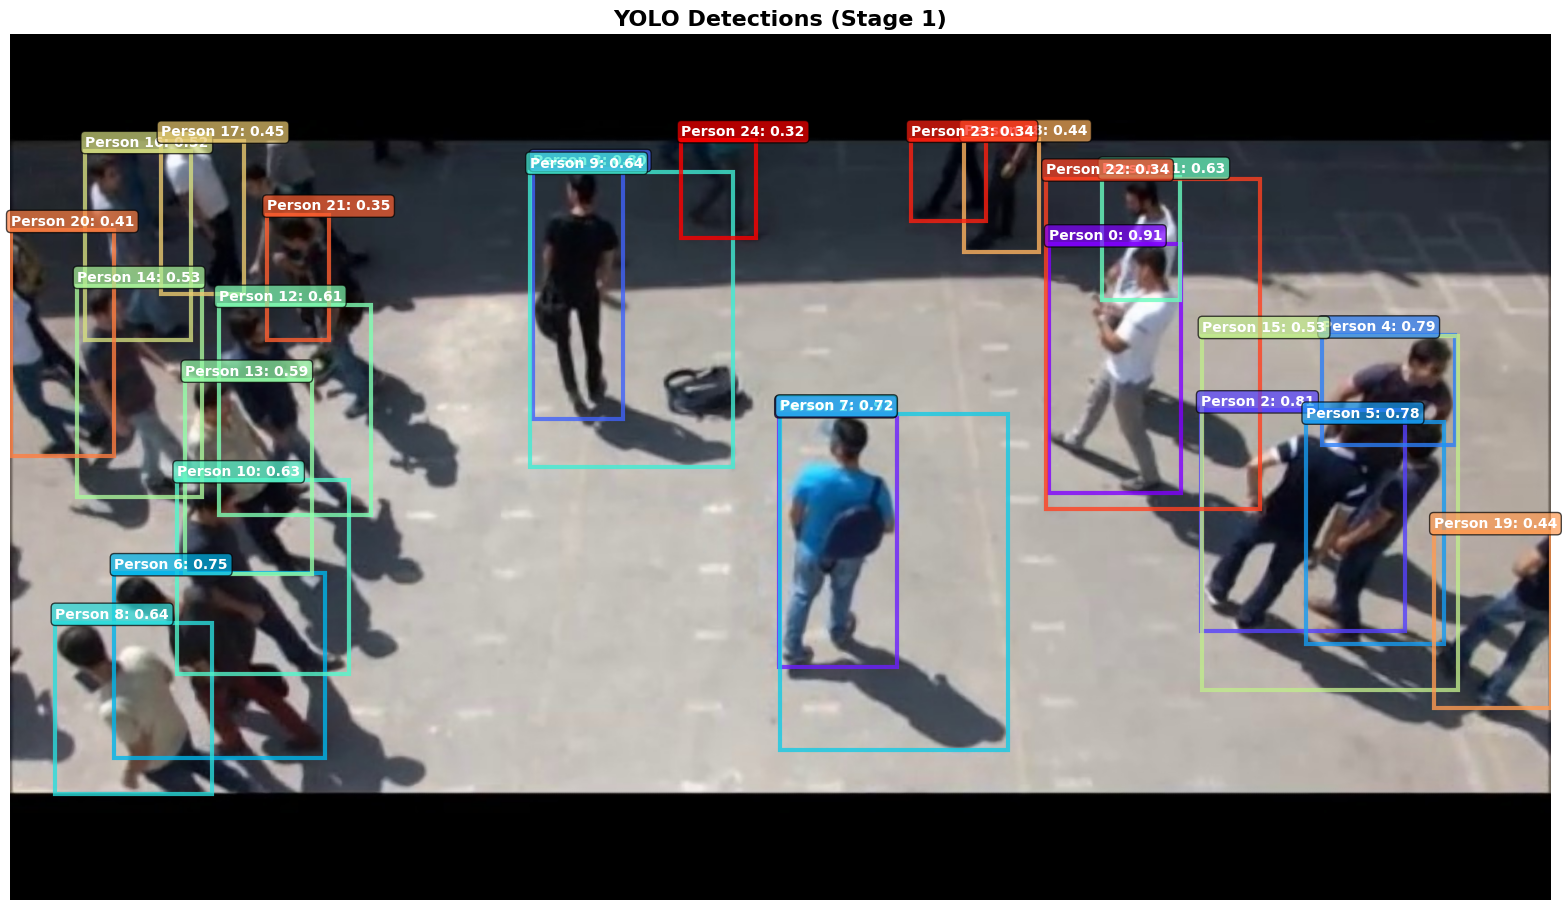

Processing 002:   0%|          | 0/6 [00:12<?, ?it/s]


KeyboardInterrupt: 

In [42]:
run_pipeline()